T3 Sprint

## Explanation of the Code

This code implements a complete workflow for fraud detection, including data preprocessing, model training, evaluation, encryption of predictions, and interpretation of results. Here’s a breakdown of what the code does:
The goal is to:

1. Train a logistic regression model to predict fraudulent transactions (isFraud) using transaction data.
2. Evaluate the model’s performance with metrics such as ROC AUC, confusion matrix, and classification report.
3. Use homomorphic encryption (via TenSEAL) to securely encrypt predictions, ensuring data privacy.
4. Interpret predictions as risk levels (e.g., "High Risk", "Moderate Risk") based on thresholds.



In [2]:
!pip install tenseal
!pip install numpy pandas scikit-learn matplotlib

# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report, roc_curve
import matplotlib.pyplot as plt
import tenseal as ts
import json
import base64
import gzip
import logging

In [3]:
# Setup logging
logging.basicConfig(level=logging.INFO)

# Specify the file path of the dataset
file_path = "SynFinData1.csv"  # Replace with your dataset's file path

# Load the dataset
data = pd.read_csv(file_path)
print("Dataset Loaded Successfully!")
print(data.head())

Dataset Loaded Successfully!
   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  
3    C38997010         21182.0             0.0        1               0  
4  M1230701703             0.0             0.0        0               0  


In [4]:
# Data Preprocessing
def preprocess_data(data):
    logging.info("Preprocessing data...")
    features = ['type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']
    target = 'isFraud'
    
    # Encode 'type' column if it's categorical
    if data['type'].dtype == 'object':
        data['type'] = data['type'].astype('category').cat.codes

    X = data[features]
    y = data[target]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    return X_train_scaled, X_test_scaled, y_train, y_test

# Model Training
def train_model(X_train, y_train):
    logging.info("Training logistic regression model...")
    model = LogisticRegression()
    model.fit(X_train, y_train)
    return model

In [5]:
# Evaluation Metrics
def evaluate_model(model, X_test, y_test):
    logging.info("Evaluating the model...")
    y_pred_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_pred_prob > 0.5).astype(int)
    
    metrics = {}
    if len(np.unique(y_test)) > 1:
        metrics['roc_auc'] = roc_auc_score(y_test, y_pred_prob)
    else:
        metrics['roc_auc'] = None
    
    metrics['conf_matrix'] = confusion_matrix(y_test, y_pred).tolist()
    metrics['classification_report'] = classification_report(y_test, y_pred, zero_division=0)
    
    return y_pred_prob, metrics

# Visualization
def plot_roc_curve(y_test, y_pred_prob):
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    plt.plot(fpr, tpr, label="ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

INFO:root:Preprocessing data...
INFO:root:Training logistic regression model...
INFO:root:Evaluating the model...


Model Metrics: {'roc_auc': np.float64(0.9560395451556142), 'conf_matrix': [[2541694, 88], [2030, 1236]], 'classification_report': '              precision    recall  f1-score   support\n\n           0       1.00      1.00      1.00   2541782\n           1       0.93      0.38      0.54      3266\n\n    accuracy                           1.00   2545048\n   macro avg       0.97      0.69      0.77   2545048\nweighted avg       1.00      1.00      1.00   2545048\n'}


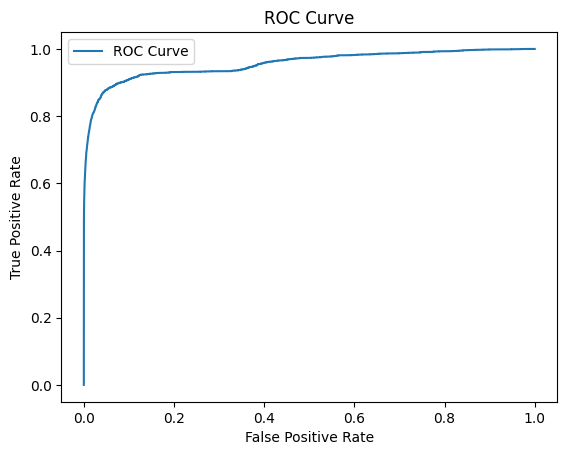

INFO:root:Initializing TenSEAL context...
INFO:root:Encrypting predictions with batching...


In [ ]:
# TenSEAL Encryption
def encrypt_predictions(predictions, context):
    logging.info("Encrypting predictions...")
    return ts.ckks_vector(context, predictions.tolist())

# Risk Interpretation
def interpret_risk(prob, thresholds={'low': 0.3, 'moderate': 0.7}):
    if prob > thresholds['moderate']:
        return "High Risk"
    elif prob > thresholds['low']:
        return "Moderate Risk"
    else:
        return "Low Risk"

def main():
    # Preprocessing
    X_train_scaled, X_test_scaled, y_train, y_test = preprocess_data(data)
    
    # Model Training
    model = train_model(X_train_scaled, y_train)
    
    # Model Evaluation
    y_pred_prob, metrics = evaluate_model(model, X_test_scaled, y_test)
    print("Model Metrics:", metrics)
    
    # Plot ROC Curve
    plot_roc_curve(y_test, y_pred_prob)
    
    # Initialize TenSEAL Context
    logging.info("Initializing TenSEAL context...")
    context = ts.context(ts.SCHEME_TYPE.CKKS, poly_modulus_degree=16384, coeff_mod_bit_sizes=[60, 40, 40, 60])
    context.global_scale = 2**40
    context.generate_galois_keys()
    
    # Batch Encrypt Predictions
    logging.info("Encrypting predictions with batching...")
    encrypted_predictions = [
        ts.ckks_vector(context, [prob]) for prob in y_pred_prob
    ]
    
    # Serialize and Compress Each Encrypted Prediction
    serialized_encrypted = [
        base64.b64encode(enc.serialize()).decode('utf-8') for enc in encrypted_predictions
    ]
    compressed_encrypted = [gzip.compress(serialized.encode('utf-8')) for serialized in serialized_encrypted]
    
    # Decrypt for Verification (One-by-One to Match Batching)
    decrypted_predictions = [
        ts.ckks_vector_from(context, base64.b64decode(enc)).decrypt()[0] 
        for enc in serialized_encrypted
    ]
    
    # Validate Decryption
    assert np.allclose(decrypted_predictions, y_pred_prob, atol=1e-4), "Decryption failed!"
    
    # Risk Interpretation
    risk_messages = [interpret_risk(prob) for prob in decrypted_predictions]
    print("Risk Interpretations:", risk_messages)
    
    # JSON Response
    response_data = {
        "model_metrics": metrics,
        "encrypted_predictions": serialized_encrypted,
        "risk_interpretations": risk_messages
    }
    response_json = json.dumps(response_data)
    
    print("Final JSON Response:")
    print(response_json)
    
    # Execute main function
if __name__ == "__main__":
    main()

## Explaination of Chunks and Model

1. Import Necessary Libraries
2. Load the Dataset

3. Data Preprocessing
Encodes Categorical Features: Converts non-numeric columns like type into numeric values using category encoding.
Splits Data: Divides the dataset into training and test sets (60%-40% split).
Scales Features: Normalizes numerical features (e.g., amount, oldbalanceOrg) using StandardScaler to improve model performance.

4. Model Training
Why Logistic Regression?
It’s a simple yet effective algorithm for binary classification problems (e.g., fraud detection).
Outputs probabilities, making it suitable for risk interpretation.
The trained model learns patterns in the data to predict whether a transaction is fraudulent.

5. Model Evaluation
The evaluate_model function assesses the model's performance:
Predictions: Generates probabilities (predict_proba) and binary predictions (>0.5 threshold).
Metrics:
ROC AUC Score: Measures the model's ability to distinguish between classes (1 = perfect, 0.5 = random).
Confusion Matrix: Shows counts of true positives, true negatives, false positives, and false negatives.
Classification Report: Provides precision, recall, F1-score, and support for each class.

6. Visualizing the ROC Curve
Plots the Receiver Operating Characteristic (ROC) Curve.
Visualizes the trade-off between true positive rate (sensitivity) and false positive rate.

7. Encrypting Predictions
Uses TenSEAL to encrypt the model's predictions (probabilities).
Ensures data privacy, as encrypted data can be shared without exposing sensitive information.

8. Homomorphic Encryption:
Allows computations on encrypted data without decrypting it, preserving confidentiality.
Encrypted predictions are decrypted and validated to ensure the encryption and decryption processes are accurate. This step uses:
serialize() to prepare encrypted data for transmission/storage.
deserialize() and decrypt() to verify that decrypted values match the original predictions.

9. Risk Interpretation
Converts predicted probabilities into human-readable risk categories:
High Risk: Probability > 70%.
Moderate Risk: Probability between 30% and 70%.
Low Risk: Probability ≤ 30%.
Provides actionable insights for stakeholders (e.g.,
